# 1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2 Load dos Dados

In [2]:
# Dataset principal
df = pd.read_csv("/content/drive/MyDrive/exercicio data/Store Sales/train.csv")

# Dataset de feriados
holidays = pd.read_csv("/content/drive/MyDrive/exercicio data/Store Sales/holidays_events.csv")

# Dataset do petróleo
oil = pd.read_csv("/content/drive/MyDrive/exercicio data/Store Sales/oil.csv")

# 3 Tratamento dos dados

In [3]:
# Converter datas
df['date'] = pd.to_datetime(df['date'])
holidays['date'] = pd.to_datetime(holidays['date'])
oil['date'] = pd.to_datetime(oil['date'])

In [4]:
# Finais de semana não possuem cotação, usar ffill para preencher com o valor anteriore
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()

In [5]:
# Remover feriados transferidos
holidays = holidays[holidays['transferred'] == False]

# Criar variável binária de feriado
holidays['is_holiday'] = 1
holidays = holidays[['date', 'is_holiday']]

# 4 Preparacao dos dados


In [6]:
# Agrupado as vendas em dia
df_daily = df.groupby('date')['sales'].sum().reset_index()

In [7]:
# Merge com holidays
df_daily = df_daily.merge(holidays, on='date', how='left')
df_daily['is_holiday'] = df_daily['is_holiday'].fillna(0)

# Merge com oil
df_daily = df_daily.merge(oil, on='date', how='left')
df_daily['dcoilwtico'] = df_daily['dcoilwtico'].ffill().bfill()

# 5 Feature Engineering

In [8]:
df_daily['year'] = df_daily['date'].dt.year
df_daily['month'] = df_daily['date'].dt.month
df_daily['dayofweek'] = df_daily['date'].dt.dayofweek
df_daily['is_weekend'] = df_daily['dayofweek'].isin([5,6]).astype(int)

In [9]:
# Índice temporal
df_daily['time_index'] = range(len(df_daily))

# Lag semanal para capturar dependência temporal das vendas
df_daily['lag_7'] = df_daily['sales'].shift(7)

# Rolling média semanal (evitando data leakage)
df_daily['rolling_mean_7'] = df_daily['sales'].shift(1).rolling(7).mean()

# Rolling média do petróleo
df_daily['oil_rolling_30'] = df_daily['dcoilwtico'].rolling(30).mean()

# Remover NaNs gerados pelos lags
df_daily = df_daily.dropna()

# 6 Analise Visual dos Dados

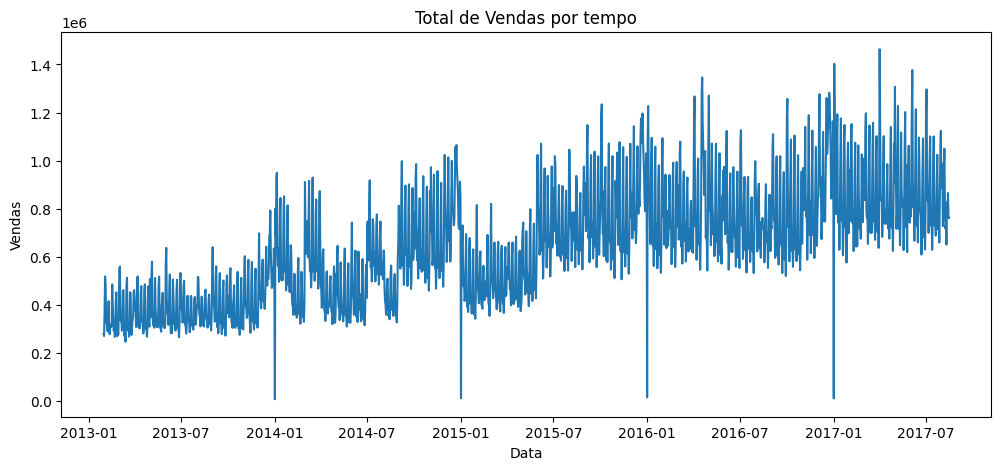

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df_daily['date'], df_daily['sales'])
plt.title("Total de Vendas por tempo")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

Text(0, 0.5, 'Vendas')

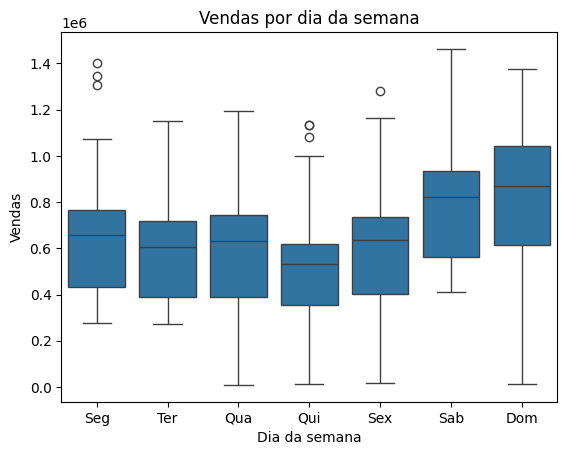

In [26]:
sns.boxplot(x='dayofweek', y='sales', data=df_daily)
plt.title("Vendas por dia da semana")
plt.xlabel("Dia da semana")
x_labels = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
plt.xticks(range(7), x_labels)
plt.ylabel("Vendas")

<Axes: >

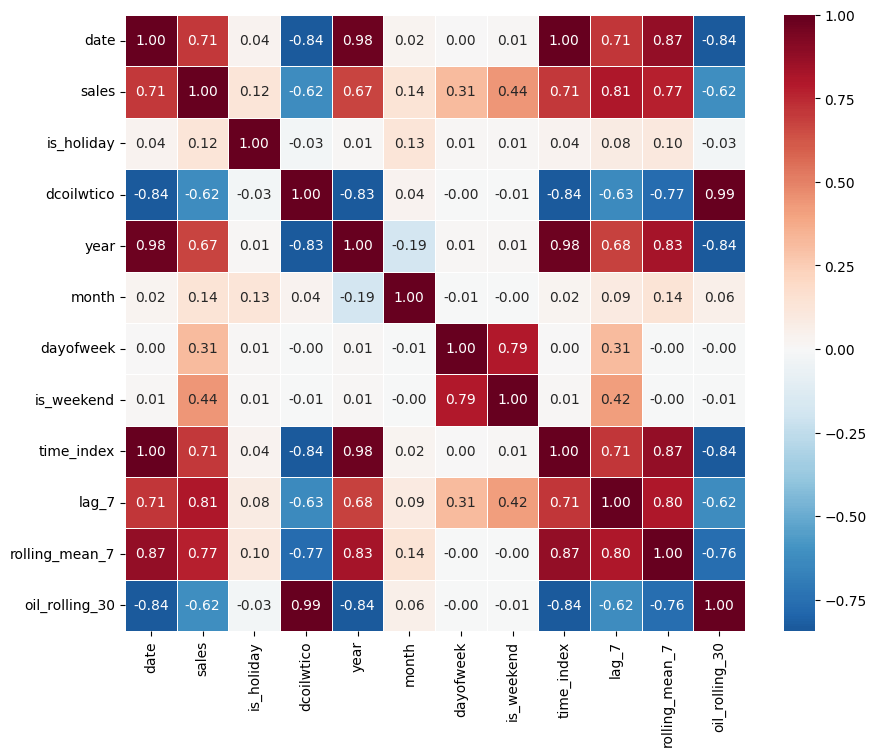

In [33]:
# Grafico de Correlacao do df_daily
corr = df_daily.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,      # Mostra os valores dentro dos quadrados
            cmap='RdBu_r',   # Paleta de cores
            fmt=".2f",       # Formata para 2 casas decimais
            linewidths=.5,   # Adiciona linhas entre os quadrados
            center=0)

# 7 Train/Test Split

In [11]:
# Últimos 90 dias como teste
cutoff = df_daily['date'].max() - pd.Timedelta(days=90)

train = df_daily[df_daily['date'] <= cutoff]
test = df_daily[df_daily['date'] > cutoff]

In [12]:
features = [
    'time_index',
    'month',
    'dayofweek',
    'is_weekend',
    'lag_7',
    'rolling_mean_7',
    'is_holiday',
    'oil_rolling_30'
]

In [13]:
X_train = train[features]
y_train = train['sales']

X_test = test[features]
y_test = test['sales']

# 8 Modelo 1 - Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [15]:
# Calculando erros
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_percent_lr = mae_lr / y_test.mean()

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("MAE Percentual:", mae_percent_lr)

Linear Regression
MAE: 85806.81287451042
RMSE: 107607.17198935668
MAE Percentual: 0.09962314455747187


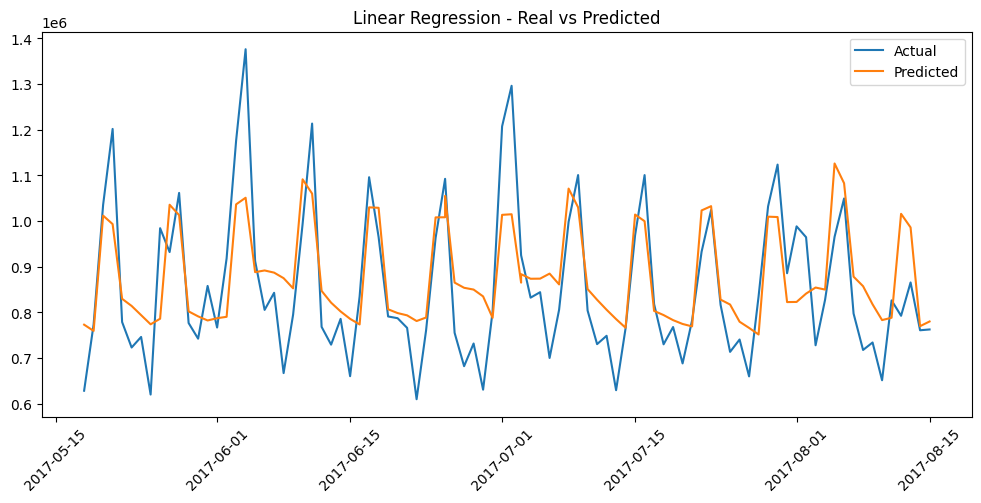

In [16]:
plt.figure(figsize=(12,5))
plt.plot(test['date'], y_test, label='Actual')
plt.plot(test['date'], pred_lr, label='Predicted')
plt.legend()
plt.xticks(rotation=45)
plt.title("Linear Regression - Real vs Predicted")
plt.show()

In [17]:
# Importância (coeficientes)
coef_lr = pd.Series(lr.coef_, index=features).sort_values(key=abs, ascending=False)
print("\nImportância - Linear Regression")
print(coef_lr)


Importância - Linear Regression
is_weekend        264101.062931
is_holiday         24771.895225
dayofweek         -11032.013843
month               3432.186969
oil_rolling_30      -135.682107
time_index            82.245165
rolling_mean_7         0.746596
lag_7                 -0.004576
dtype: float64


In [18]:
# R2 treino
r2_train_lr = r2_score(y_train, lr.predict(X_train))

# R2 teste
r2_test_lr = r2_score(y_test, pred_lr)

print("Linear Regression")
print("R2 Treino:", r2_train_lr)
print("R2 Teste :", r2_test_lr)

Linear Regression
R2 Treino: 0.7987895194745607
R2 Teste : 0.5757132606125421


# 9 Modelo 2 - Random Forest

In [19]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [20]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_percent_rf = mae_rf / y_test.mean()

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("MAE Percentual:", mae_percent_rf)

Random Forest
MAE: 65931.86098103892
RMSE: 89302.50985645776
MAE Percentual: 0.07654799307210204


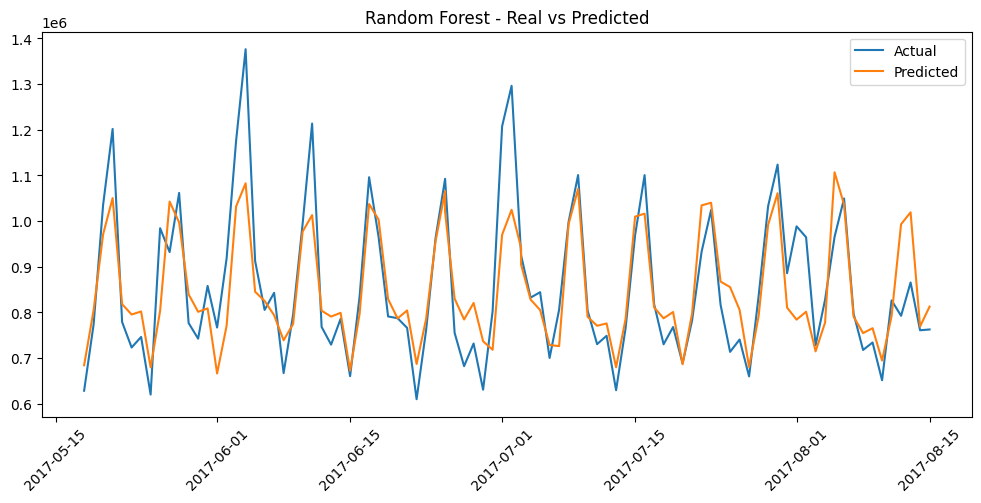

In [21]:
plt.figure(figsize=(12,5))
plt.plot(test['date'], y_test, label='Actual')
plt.plot(test['date'], pred_rf, label='Predicted')
plt.legend()
plt.xticks(rotation=45)
plt.title("Random Forest - Real vs Predicted")
plt.show()

In [22]:
feat_importance_rf = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportância - Random Forest")
print(feat_importance_rf)


Importância - Random Forest
lag_7             0.386523
rolling_mean_7    0.346691
dayofweek         0.084307
time_index        0.057759
is_weekend        0.054307
oil_rolling_30    0.034719
month             0.025610
is_holiday        0.010084
dtype: float64


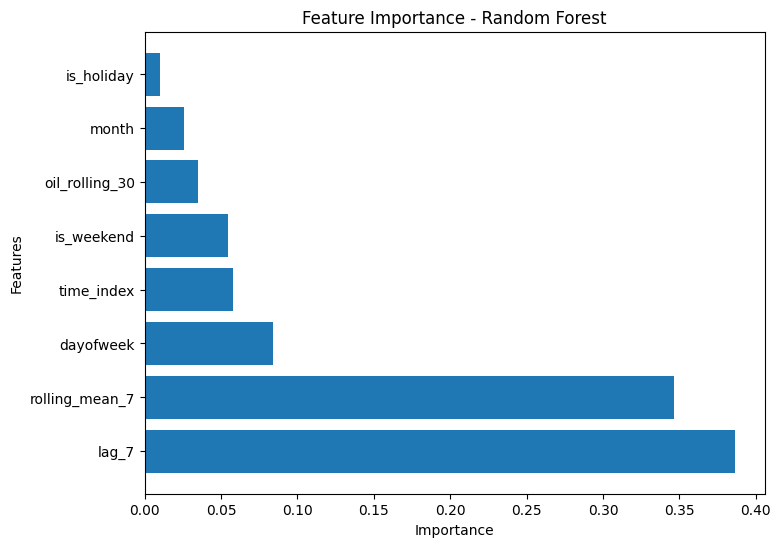

In [23]:
# Plot
plt.figure(figsize=(8,6))
plt.barh(feat_importance_rf.index, feat_importance_rf.values)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [24]:
# R2 treino
r2_train_rf = r2_score(y_train, rf.predict(X_train))

# R2 teste
r2_test_rf = r2_score(y_test, pred_rf)

print("Random Forest")
print("R2 Treino:", r2_train_rf)
print("R2 Teste :", r2_test_rf)


Random Forest
R2 Treino: 0.978047775938777
R2 Teste : 0.7077837570601064


In [40]:
# Baseline para mostrar que o modelo é melhor que algo mais simples
baseline_pred = test['lag_7']
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline RMSE:", baseline_rmse)
print("Random Forest RMSE:", rmse_rf)

Baseline RMSE: 145199.199398682
Random Forest RMSE: 89302.50985645776


 - Random Forest apresentou menor erro que Linear Regression,
indicando presença de relações não lineares nas vendas.

Próximos passos:

Normalização nos dados - StandardScaler

TimeSeriesSplit

Cross-validation temporal

GridSearch no RandomForest